# <img src="https://raw.githubusercontent.com/iterative/datachain/main/docs/assets/datachain.svg" style="height: 32px; width: 32px; vertical-align: bottom"/> Tutorial: Working with Video Datasets

This tutorial dives into techniques to manage video datasets datasets.

**📋 Topics covered:**
1. Building a Video DataChain for [AVA Actions](https://research.google.com/ava/) video dataset
2. Creating a Data Model for YOLOv11 Pose Detection projects
3. Integrating Video-Level Annotations from CSV
5. Extract and Manage Video Frames
6. Running Pose Detection with YOLOv11 and Saving to DataChain
7. Visualizing Pose Data

## Setup

To start, install the dependencies.

In [1]:
%pip install -q 'datachain[video]'


[notice] A new release of pip is available: 24.3.1 -> 25.0
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Get data and create DataChain

We will use **AVA Actions dataset** from [https://research.google.com/ava/download.html](https://research.google.com/ava/download.html#ava_actions_download). To download dataset, use the following script:

In [2]:
%%bash

# Download video files list
DATA_DIR="data/ava"
mkdir -p ${DATA_DIR}

wget -q https://s3.amazonaws.com/ava-dataset/annotations/ava_file_names_trainval_v2.1.txt -O ${DATA_DIR}/ava_file_names_trainval_v2.1.txt

# Download video files
VIDEOS_DIR="${DATA_DIR}/videos"
mkdir -p ${VIDEOS_DIR}

for file in $(cat ${DATA_DIR}/ava_file_names_trainval_v2.1.txt | head -3); do
    echo -n "Download '${file}'... "
    if [[ ! -f ${VIDEOS_DIR}/${file} ]]; then
        wget -q https://s3.amazonaws.com/ava-dataset/trainval/${file} -P ${VIDEOS_DIR}
    fi
    echo "OK"
done

# Download annotations
ANNOTATIONS_DIR="${DATA_DIR}/annotations"
mkdir -p ${ANNOTATIONS_DIR}

wget -q https://research.google.com/ava/download/ava_v2.2.zip -O ${DATA_DIR}/ava_v2.2.zip
unzip -qo ${DATA_DIR}/ava_v2.2.zip -d ${ANNOTATIONS_DIR}

# Prepare output directory for video fragments
mkdir -p ${DATA_DIR}/fragments

# Prepare output directory for video frames
mkdir -p ${DATA_DIR}/frames

Download '_-Z6wFjXtGQ.mkv'... OK
Download '_145Aa_xkuE.mp4'... OK
Download '_7oWZq_s_Sk.mkv'... OK


### Indexing storage

To create a chain from a directory of files, use `DataChain.from_storage()` and point to the location of the directory:

In [3]:
from datachain import DataChain

repo_dc = DataChain.from_storage("./data/ava/videos", type="video", update=True)
repo_dc.show(10)

Processed: 0 rows [00:00, ? rows/s]

Listing file:///Users/vlad/work/iterative/datachain-examples/video/data/ava/videos: 0 objects [00:00, ? object…

Generated: 0 rows [00:00, ? rows/s]

Cleanup:   0%|          | 0/1 [00:00<?, ? tables/s]

,file,file,file,file,file,file,file,file
,source,path,size,version,etag,is_latest,last_modified,location
0,file:///Users/vlad/work/iterative/datachain-ex...,9Y_l9NsnYE0.mp4,299051037,,0x1.6a6d311c00000p+30,1,2018-03-04 01:30:47+00:00,None
1,file:///Users/vlad/work/iterative/datachain-ex...,G4qq1MRXCiY.mkv,204727729,,0x1.6a6eceec00000p+30,1,2018-03-04 08:52:11+00:00,None
2,file:///Users/vlad/work/iterative/datachain-ex...,4gVsDd8PV9U.mp4,587579944,,0x1.6a6c6bb400000p+30,1,2018-03-03 22:00:13+00:00,None
3,file:///Users/vlad/work/iterative/datachain-ex...,c9pEMjPT16M.webm,340432181,,0x1.6a6de73000000p+30,1,2018-03-04 04:45:00+00:00,None
4,file:///Users/vlad/work/iterative/datachain-ex...,Gt61_Yekkgc.mp4,326660841,,0x1.6a6f0d3400000p+30,1,2018-03-04 09:58:37+00:00,None
5,file:///Users/vlad/work/iterative/datachain-ex...,-IELREHX_js.mp4,125710755,,0x1.6a6c20ec00000p+30,1,2018-03-03 20:40:27+00:00,None
6,file:///Users/vlad/work/iterative/datachain-ex...,0wBYFahr3uI.mp4,274752600,,0x1.6a6c317c00000p+30,1,2018-03-03 20:58:07+00:00,None
7,file:///Users/vlad/work/iterative/datachain-ex...,bePts02nIY8.mkv,272741181,,0x1.6a6dcdc400000p+30,1,2018-03-04 04:17:53+00:00,None
8,file:///Users/vlad/work/iterative/datachain-ex...,bSZiZ4rOC7c.mkv,220409224,,0x1.6a6dd5d000000p+30,1,2018-03-04 04:26:28+00:00,None



[Limited by 10 rows]


DataChain created a record for each file in the repository, generating a `file` signal for each file. The file signal contains subsignals with metadata about each file, like `file.name` and `file.size`. By default all `file` signals will have `File` type, by using `type="video"` param we can specify type of the files to `VideoFile`.

## Adding video meta information

In [4]:
from datachain.lib.file import Video

repo_dc2 = repo_dc.map(lambda file: file.get_info(), output={'meta': Video}).save()
repo_dc2.show(10)

Preparing: 0 rows [00:00, ? rows/s]

Processed: 0 rows [00:00, ? rows/s]

Cleanup:   0%|          | 0/2 [00:00<?, ? tables/s]

,file,file,file,file,file,file,file,file,meta,meta,meta,meta,meta,meta,meta
,source,path,size,version,etag,is_latest,last_modified,location,width,height,fps,duration,frames,format,codec
0,file:///Users/vlad/work/iterative/datachain-ex...,9Y_l9NsnYE0.mp4,299051037,,0x1.6a6d311c00000p+30,1,2018-03-04 01:30:47+00:00,None,640,480,25.000000,3517.880000,87947,"mov,mp4,m4a,3gp,3g2,mj2",h264
1,file:///Users/vlad/work/iterative/datachain-ex...,G4qq1MRXCiY.mkv,204727729,,0x1.6a6eceec00000p+30,1,2018-03-04 08:52:11+00:00,None,854,480,25.000000,2507.221000,62681,"matroska,webm",h264
2,file:///Users/vlad/work/iterative/datachain-ex...,4gVsDd8PV9U.mp4,587579944,,0x1.6a6c6bb400000p+30,1,2018-03-03 22:00:13+00:00,None,854,480,29.970030,4948.910633,148319,"mov,mp4,m4a,3gp,3g2,mj2",h264
3,file:///Users/vlad/work/iterative/datachain-ex...,c9pEMjPT16M.webm,340432181,,0x1.6a6de73000000p+30,1,2018-03-04 04:45:00+00:00,None,440,360,29.970030,7141.901000,214043,"matroska,webm",vp9
4,file:///Users/vlad/work/iterative/datachain-ex...,Gt61_Yekkgc.mp4,326660841,,0x1.6a6f0d3400000p+30,1,2018-03-04 09:58:37+00:00,None,1280,720,25.000000,1916.388889,47910,"mov,mp4,m4a,3gp,3g2,mj2",h264
5,file:///Users/vlad/work/iterative/datachain-ex...,-IELREHX_js.mp4,125710755,,0x1.6a6c20ec00000p+30,1,2018-03-03 20:40:27+00:00,None,640,342,25.000000,2604.094694,65102,"mov,mp4,m4a,3gp,3g2,mj2",h264
6,file:///Users/vlad/work/iterative/datachain-ex...,0wBYFahr3uI.mp4,274752600,,0x1.6a6c317c00000p+30,1,2018-03-03 20:58:07+00:00,None,640,480,23.976024,3307.055601,79290,"mov,mp4,m4a,3gp,3g2,mj2",h264
7,file:///Users/vlad/work/iterative/datachain-ex...,bePts02nIY8.mkv,272741181,,0x1.6a6dcdc400000p+30,1,2018-03-04 04:17:53+00:00,None,854,480,29.970030,4744.721000,142200,"matroska,webm",h264
8,file:///Users/vlad/work/iterative/datachain-ex...,bSZiZ4rOC7c.mkv,220409224,,0x1.6a6dd5d000000p+30,1,2018-03-04 04:26:28+00:00,None,640,480,25.000000,4035.641000,100891,"matroska,webm",h264



[Limited by 10 rows]


### Adding YouTube video ID

We will need YouTube video ID to process files. Let's create mapper to add `video_id` signal:

In [5]:
repo_dc3 = repo_dc2.map(lambda file: file.path[:11], output={'video_id': str}).save()
repo_dc3.show(10)

Preparing: 0 rows [00:00, ? rows/s]

Processed: 0 rows [00:00, ? rows/s]

Cleanup:   0%|          | 0/2 [00:00<?, ? tables/s]

,file,file,file,file,file,file,file,file,meta,meta,meta,meta,meta,meta,meta,video_id
,source,path,size,version,etag,is_latest,last_modified,location,width,height,fps,duration,frames,format,codec,
0,file:///Users/vlad/work/iterative/datachain-ex...,9Y_l9NsnYE0.mp4,299051037,,0x1.6a6d311c00000p+30,1,2018-03-04 01:30:47+00:00,None,640,480,25.000000,3517.880000,87947,"mov,mp4,m4a,3gp,3g2,mj2",h264,9Y_l9NsnYE0
1,file:///Users/vlad/work/iterative/datachain-ex...,G4qq1MRXCiY.mkv,204727729,,0x1.6a6eceec00000p+30,1,2018-03-04 08:52:11+00:00,None,854,480,25.000000,2507.221000,62681,"matroska,webm",h264,G4qq1MRXCiY
2,file:///Users/vlad/work/iterative/datachain-ex...,4gVsDd8PV9U.mp4,587579944,,0x1.6a6c6bb400000p+30,1,2018-03-03 22:00:13+00:00,None,854,480,29.970030,4948.910633,148319,"mov,mp4,m4a,3gp,3g2,mj2",h264,4gVsDd8PV9U
3,file:///Users/vlad/work/iterative/datachain-ex...,c9pEMjPT16M.webm,340432181,,0x1.6a6de73000000p+30,1,2018-03-04 04:45:00+00:00,None,440,360,29.970030,7141.901000,214043,"matroska,webm",vp9,c9pEMjPT16M
4,file:///Users/vlad/work/iterative/datachain-ex...,Gt61_Yekkgc.mp4,326660841,,0x1.6a6f0d3400000p+30,1,2018-03-04 09:58:37+00:00,None,1280,720,25.000000,1916.388889,47910,"mov,mp4,m4a,3gp,3g2,mj2",h264,Gt61_Yekkgc
5,file:///Users/vlad/work/iterative/datachain-ex...,-IELREHX_js.mp4,125710755,,0x1.6a6c20ec00000p+30,1,2018-03-03 20:40:27+00:00,None,640,342,25.000000,2604.094694,65102,"mov,mp4,m4a,3gp,3g2,mj2",h264,-IELREHX_js
6,file:///Users/vlad/work/iterative/datachain-ex...,0wBYFahr3uI.mp4,274752600,,0x1.6a6c317c00000p+30,1,2018-03-03 20:58:07+00:00,None,640,480,23.976024,3307.055601,79290,"mov,mp4,m4a,3gp,3g2,mj2",h264,0wBYFahr3uI
7,file:///Users/vlad/work/iterative/datachain-ex...,bePts02nIY8.mkv,272741181,,0x1.6a6dcdc400000p+30,1,2018-03-04 04:17:53+00:00,None,854,480,29.970030,4744.721000,142200,"matroska,webm",h264,bePts02nIY8
8,file:///Users/vlad/work/iterative/datachain-ex...,bSZiZ4rOC7c.mkv,220409224,,0x1.6a6dd5d000000p+30,1,2018-03-04 04:26:28+00:00,None,640,480,25.000000,4035.641000,100891,"matroska,webm",h264,bSZiZ4rOC7c



[Limited by 10 rows]


### Create annotations DataChain

Each row in annotations CSV file contains an annotation for one person performing an action in an interval, where that annotation is associated with the middle frame. Different persons and multiple action labels are described in separate rows.

The format of a row is the following: `video_id`, `middle_frame_timestamp`, `person_box`, `action_id`, `person_id`

- `video_id`: YouTube identifier
- `middle_frame_timestamp`: in seconds from the start of the YouTube.
- `person_box`: top-left (x1, y1) and bottom-right (x2,y2) normalized with respect to frame size, where (0.0, 0.0) corresponds to the top left, and (1.0, 1.0) corresponds to bottom right.
- `action_id`: identifier of an action class, see ava_action_list_v2.2.pbtxt
- `person_id`: a unique integer allowing this box to be linked to other boxes depicting the same person in adjacent frames of this video.

In [6]:
from datachain import DataChain, DataModel

class AvaMeta(DataModel):
    video_id: str
    timestamp: int
    box_left: float
    box_top: float
    box_right: float
    box_bottom: float
    action_id: int
    person_id: int

annotations_dc = DataChain.from_csv(
    "./data/ava/annotations/ava_train_v2.2.csv",
    output=AvaMeta,
    source=False,
    settings={'prefetch': 0, 'cache': False},
).save()
annotations_dc.show(10)

Processed: 0 rows [00:00, ? rows/s]

Generated: 0 rows [00:00, ? rows/s]

Cleanup:   0%|          | 0/1 [00:00<?, ? tables/s]

Processed: 0 rows [00:00, ? rows/s]

Generated: 0 rows [00:00, ? rows/s]

...

Parsed by pyarrow: 0rows [00:00, ?rows/s]

Generated: 0 rows [00:00, ? rows/s]

Cleanup:   0%|          | 0/3 [00:00<?, ? tables/s]

,video_id,timestamp,box_left,box_top,box_right,box_bottom,action_id,person_id
0,-5KQ66BBWC4,902,0.077,0.151,0.283,0.811,9,1
1,-5KQ66BBWC4,902,0.226,0.032,0.366,0.497,12,0
2,-5KQ66BBWC4,902,0.226,0.032,0.366,0.497,17,0
3,-5KQ66BBWC4,902,0.226,0.032,0.366,0.497,80,0
4,-5KQ66BBWC4,902,0.332,0.194,0.481,0.891,80,2
5,-5KQ66BBWC4,902,0.332,0.194,0.481,0.891,9,2
6,-5KQ66BBWC4,902,0.505,0.105,0.653,0.780,9,3
7,-5KQ66BBWC4,902,0.626,0.146,0.805,0.818,9,5
8,-5KQ66BBWC4,902,0.805,0.222,0.997,1.000,80,4
9,-5KQ66BBWC4,902,0.805,0.222,0.997,1.000,9,4



[Limited by 10 rows]


Action classes:

In [7]:
actions = {
    1: {'name': 'bend/bow (at the waist)', 'cls': 'PERSON_MOVEMENT'},
    2: {'name': 'crawl', 'cls': 'PERSON_MOVEMENT'},
    3: {'name': 'crouch/kneel', 'cls': 'PERSON_MOVEMENT'},
    4: {'name': 'dance', 'cls': 'PERSON_MOVEMENT'},
    5: {'name': 'fall down', 'cls': 'PERSON_MOVEMENT'},
    6: {'name': 'get up', 'cls': 'PERSON_MOVEMENT'},
    7: {'name': 'jump/leap', 'cls': 'PERSON_MOVEMENT'},
    8: {'name': 'lie/sleep', 'cls': 'PERSON_MOVEMENT'},
    9: {'name': 'martial art', 'cls': 'PERSON_MOVEMENT'},
    10: {'name': 'run/jog', 'cls': 'PERSON_MOVEMENT'},
    11: {'name': 'sit', 'cls': 'PERSON_MOVEMENT'},
    12: {'name': 'stand', 'cls': 'PERSON_MOVEMENT'},
    13: {'name': 'swim', 'cls': 'PERSON_MOVEMENT'},
    14: {'name': 'walk', 'cls': 'PERSON_MOVEMENT'},
    15: {'name': 'answer phone', 'cls': 'OBJECT_MANIPULATION'},
    16: {'name': 'brush teeth', 'cls': 'OBJECT_MANIPULATION'},
    17: {'name': 'carry/hold (an object)', 'cls': 'OBJECT_MANIPULATION'},
    18: {'name': 'catch (an object)', 'cls': 'OBJECT_MANIPULATION'},
    19: {'name': 'chop', 'cls': 'OBJECT_MANIPULATION'},
    20: {'name': 'climb (e.g., a mountain)', 'cls': 'OBJECT_MANIPULATION'},
    21: {'name': 'clink glass', 'cls': 'OBJECT_MANIPULATION'},
    22: {'name': 'close (e.g., a door, a box)', 'cls': 'OBJECT_MANIPULATION'},
    23: {'name': 'cook', 'cls': 'OBJECT_MANIPULATION'},
    24: {'name': 'cut', 'cls': 'OBJECT_MANIPULATION'},
    25: {'name': 'dig', 'cls': 'OBJECT_MANIPULATION'},
    26: {'name': 'dress/put on clothing', 'cls': 'OBJECT_MANIPULATION'},
    27: {'name': 'drink', 'cls': 'OBJECT_MANIPULATION'},
    28: {'name': 'drive (e.g., a car, a truck)', 'cls': 'OBJECT_MANIPULATION'},
    29: {'name': 'eat', 'cls': 'OBJECT_MANIPULATION'},
    30: {'name': 'enter', 'cls': 'OBJECT_MANIPULATION'},
    31: {'name': 'exit', 'cls': 'OBJECT_MANIPULATION'},
    32: {'name': 'extract', 'cls': 'OBJECT_MANIPULATION'},
    33: {'name': 'fishing', 'cls': 'OBJECT_MANIPULATION'},
    34: {'name': 'hit (an object)', 'cls': 'OBJECT_MANIPULATION'},
    35: {'name': 'kick (an object)', 'cls': 'OBJECT_MANIPULATION'},
    36: {'name': 'lift/pick up', 'cls': 'OBJECT_MANIPULATION'},
    37: {'name': 'listen (e.g., to music)', 'cls': 'OBJECT_MANIPULATION'},
    38: {'name': 'open (e.g., a window, a car door)', 'cls': 'OBJECT_MANIPULATION'},
    39: {'name': 'paint', 'cls': 'OBJECT_MANIPULATION'},
    40: {'name': 'play board game', 'cls': 'OBJECT_MANIPULATION'},
    41: {'name': 'play musical instrument', 'cls': 'OBJECT_MANIPULATION'},
    42: {'name': 'play with pets', 'cls': 'OBJECT_MANIPULATION'},
    43: {'name': 'point to (an object)', 'cls': 'OBJECT_MANIPULATION'},
    44: {'name': 'press', 'cls': 'OBJECT_MANIPULATION'},
    45: {'name': 'pull (an object)', 'cls': 'OBJECT_MANIPULATION'},
    46: {'name': 'push (an object)', 'cls': 'OBJECT_MANIPULATION'},
    47: {'name': 'put down', 'cls': 'OBJECT_MANIPULATION'},
    48: {'name': 'read', 'cls': 'OBJECT_MANIPULATION'},
    49: {'name': 'ride (e.g., a bike, a car, a horse)', 'cls': 'OBJECT_MANIPULATION'},
    50: {'name': 'row boat', 'cls': 'OBJECT_MANIPULATION'},
    51: {'name': 'sail boat', 'cls': 'OBJECT_MANIPULATION'},
    52: {'name': 'shoot', 'cls': 'OBJECT_MANIPULATION'},
    53: {'name': 'shovel', 'cls': 'OBJECT_MANIPULATION'},
    54: {'name': 'smoke', 'cls': 'OBJECT_MANIPULATION'},
    55: {'name': 'stir', 'cls': 'OBJECT_MANIPULATION'},
    56: {'name': 'take a photo', 'cls': 'OBJECT_MANIPULATION'},
    57: {'name': 'text on/look at a cellphone', 'cls': 'OBJECT_MANIPULATION'},
    58: {'name': 'throw', 'cls': 'OBJECT_MANIPULATION'},
    59: {'name': 'touch (an object)', 'cls': 'OBJECT_MANIPULATION'},
    60: {'name': 'turn (e.g., a screwdriver)', 'cls': 'OBJECT_MANIPULATION'},
    61: {'name': 'watch (e.g., TV)', 'cls': 'OBJECT_MANIPULATION'},
    62: {'name': 'work on a computer', 'cls': 'OBJECT_MANIPULATION'},
    63: {'name': 'write', 'cls': 'OBJECT_MANIPULATION'},
    64: {'name': 'fight/hit (a person)', 'cls': 'PERSON_INTERACTION'},
    65: {'name': 'give/serve (an object) to (a person)', 'cls': 'PERSON_INTERACTION'},
    66: {'name': 'grab (a person)', 'cls': 'PERSON_INTERACTION'},
    67: {'name': 'hand clap', 'cls': 'PERSON_INTERACTION'},
    68: {'name': 'hand shake', 'cls': 'PERSON_INTERACTION'},
    69: {'name': 'hand wave', 'cls': 'PERSON_INTERACTION'},
    70: {'name': 'hug (a person)', 'cls': 'PERSON_INTERACTION'},
    71: {'name': 'kick (a person)', 'cls': 'PERSON_INTERACTION'},
    72: {'name': 'kiss (a person)', 'cls': 'PERSON_INTERACTION'},
    73: {'name': 'lift (a person)', 'cls': 'PERSON_INTERACTION'},
    74: {'name': 'listen to (a person)', 'cls': 'PERSON_INTERACTION'},
    75: {'name': 'play with kids', 'cls': 'PERSON_INTERACTION'},
    76: {'name': 'push (another person)', 'cls': 'PERSON_INTERACTION'},
    77: {'name': 'sing to (e.g., self, a person, a group)', 'cls': 'PERSON_INTERACTION'},
    78: {'name': 'take (an object) from (a person)', 'cls': 'PERSON_INTERACTION'},
    79: {'name': 'talk to (e.g., self, a person, a group)', 'cls': 'PERSON_INTERACTION'},
    80: {'name': 'watch (a person)', 'cls': 'PERSON_INTERACTION'}
}

## Video frames processing

For example, let's find all frames with **answer phone** action (`action_id = 15`):

In [8]:
from datachain import C

dance_frames_dc = annotations_dc.filter(C("action_id") == 15)
dance_frames_dc.show(10)

,video_id,timestamp,box_left,box_top,box_right,box_bottom,action_id,person_id
0,-OyDO1g74vc,934,0.384,0.396,0.500,0.659,15,3
1,-OyDO1g74vc,935,0.378,0.388,0.488,0.649,15,3
2,-OyDO1g74vc,936,0.459,0.449,0.570,0.694,15,3
3,-OyDO1g74vc,966,0.306,0.206,0.719,0.981,15,4
4,-OyDO1g74vc,967,0.342,0.160,0.713,0.988,15,4
5,-OyDO1g74vc,968,0.309,0.159,0.673,0.986,15,4
6,-OyDO1g74vc,969,0.302,0.148,0.697,0.980,15,4
7,-OyDO1g74vc,970,0.305,0.144,0.680,0.981,15,4
8,-OyDO1g74vc,971,0.340,0.076,0.713,0.969,15,4
9,-OyDO1g74vc,972,0.324,0.055,0.720,0.967,15,4



[Limited by 10 rows]


Build models from these frames:

In [9]:
repo_video_frame_dc = repo_dc3.merge(
    dance_frames_dc,
    on="video_id",
    right_on="video_id",
    inner=True,
)
repo_video_frame_dc.show(10)

,file,file,file,file,file,file,file,file,meta,meta,meta,meta,meta,meta,meta,video_id,right_video_id,timestamp,box_left,box_top,box_right,box_bottom,action_id,person_id
,source,path,size,version,etag,is_latest,last_modified,location,width,height,fps,duration,frames,format,codec,,,,,,,,,
0,file:///Users/vlad/work/iterative/datachain-ex...,-OyDO1g74vc.mp4,223253723,,0x1.6a6c225c00000p+30,1,2018-03-03 20:41:59+00:00,None,466,360,25.0,4174.413787,104360,"mov,mp4,m4a,3gp,3g2,mj2",h264,-OyDO1g74vc,-OyDO1g74vc,934,0.384,0.396,0.500,0.659,15,3
1,file:///Users/vlad/work/iterative/datachain-ex...,-OyDO1g74vc.mp4,223253723,,0x1.6a6c225c00000p+30,1,2018-03-03 20:41:59+00:00,None,466,360,25.0,4174.413787,104360,"mov,mp4,m4a,3gp,3g2,mj2",h264,-OyDO1g74vc,-OyDO1g74vc,935,0.378,0.388,0.488,0.649,15,3
2,file:///Users/vlad/work/iterative/datachain-ex...,-OyDO1g74vc.mp4,223253723,,0x1.6a6c225c00000p+30,1,2018-03-03 20:41:59+00:00,None,466,360,25.0,4174.413787,104360,"mov,mp4,m4a,3gp,3g2,mj2",h264,-OyDO1g74vc,-OyDO1g74vc,936,0.459,0.449,0.570,0.694,15,3
3,file:///Users/vlad/work/iterative/datachain-ex...,-OyDO1g74vc.mp4,223253723,,0x1.6a6c225c00000p+30,1,2018-03-03 20:41:59+00:00,None,466,360,25.0,4174.413787,104360,"mov,mp4,m4a,3gp,3g2,mj2",h264,-OyDO1g74vc,-OyDO1g74vc,966,0.306,0.206,0.719,0.981,15,4
4,file:///Users/vlad/work/iterative/datachain-ex...,-OyDO1g74vc.mp4,223253723,,0x1.6a6c225c00000p+30,1,2018-03-03 20:41:59+00:00,None,466,360,25.0,4174.413787,104360,"mov,mp4,m4a,3gp,3g2,mj2",h264,-OyDO1g74vc,-OyDO1g74vc,967,0.342,0.160,0.713,0.988,15,4
5,file:///Users/vlad/work/iterative/datachain-ex...,-OyDO1g74vc.mp4,223253723,,0x1.6a6c225c00000p+30,1,2018-03-03 20:41:59+00:00,None,466,360,25.0,4174.413787,104360,"mov,mp4,m4a,3gp,3g2,mj2",h264,-OyDO1g74vc,-OyDO1g74vc,968,0.309,0.159,0.673,0.986,15,4
6,file:///Users/vlad/work/iterative/datachain-ex...,-OyDO1g74vc.mp4,223253723,,0x1.6a6c225c00000p+30,1,2018-03-03 20:41:59+00:00,None,466,360,25.0,4174.413787,104360,"mov,mp4,m4a,3gp,3g2,mj2",h264,-OyDO1g74vc,-OyDO1g74vc,969,0.302,0.148,0.697,0.980,15,4
7,file:///Users/vlad/work/iterative/datachain-ex...,-OyDO1g74vc.mp4,223253723,,0x1.6a6c225c00000p+30,1,2018-03-03 20:41:59+00:00,None,466,360,25.0,4174.413787,104360,"mov,mp4,m4a,3gp,3g2,mj2",h264,-OyDO1g74vc,-OyDO1g74vc,970,0.305,0.144,0.680,0.981,15,4
8,file:///Users/vlad/work/iterative/datachain-ex...,-OyDO1g74vc.mp4,223253723,,0x1.6a6c225c00000p+30,1,2018-03-03 20:41:59+00:00,None,466,360,25.0,4174.413787,104360,"mov,mp4,m4a,3gp,3g2,mj2",h264,-OyDO1g74vc,-OyDO1g74vc,971,0.340,0.076,0.713,0.969,15,4



[Limited by 10 rows]


Save video frames along with BBox (bounding box) model:

In [10]:
from datachain.lib.file import Video, VideoFrame, VideoFile
from datachain.model import BBox

def process(
    file: VideoFile,
    meta: Video,
    timestamp: int,
    box_left: float,
    box_top: float,
    box_right: float,
    box_bottom: float,
):
    if not file.get_local_path():
        return
    file_stem = file.get_file_stem()
    file_ext = file.get_file_ext()
    file_name = f"{file_stem}_{timestamp}.jpg"
    file_path = f"data/ava/frames/{file_name}"
    frame = file.save_frame(round(timestamp * meta.fps), file_path)
    bbox = BBox.from_list(coords=[
        round(box_left * meta.width),
        round(box_top * meta.height),
        round(box_right * meta.width),
        round(box_bottom * meta.height),
    ])
    yield frame, bbox

frames_dc = repo_video_frame_dc.limit(100).gen(process, output={"file": VideoFrame, "box": BBox}).save()
frames_dc.show(10)

Processed: 0 rows [00:00, ? rows/s]

Generated: 0 rows [00:00, ? rows/s]

Cleanup:   0%|          | 0/1 [00:00<?, ? tables/s]

,file,file,file,file,file,file,file,file,file,file,file,file,file,file,file,file,file,file,box,box
,source,path,size,version,etag,is_latest,last_modified,location,frame,timestamp,orig,orig,orig,orig,orig,orig,orig,orig,title,coords
,,,,,,,,,,,source,path,size,version,etag,is_latest,last_modified,location,,
0,file:///Users/vlad/work/iterative/datachain-ex...,-OyDO1g74vc_934.jpg,20462,,0x1.9e5f2328d7dedp+30,1,2025-01-27 17:56:26.210811+00:00,None,23350,934.0,file:///Users/vlad/work/iterative/datachain-ex...,-OyDO1g74vc.mp4,223253723,,0x1.6a6c225c00000p+30,1,2018-03-03 20:41:59+00:00,None,,"[179, 143, 233, 237]"
1,file:///Users/vlad/work/iterative/datachain-ex...,-OyDO1g74vc_935.jpg,21254,,0x1.9e5f232972b49p+30,1,2025-01-27 17:56:26.362017+00:00,None,23375,935.0,file:///Users/vlad/work/iterative/datachain-ex...,-OyDO1g74vc.mp4,223253723,,0x1.6a6c225c00000p+30,1,2018-03-03 20:41:59+00:00,None,,"[176, 140, 227, 234]"
2,file:///Users/vlad/work/iterative/datachain-ex...,-OyDO1g74vc_936.jpg,17890,,0x1.9e5f232a14c59p+30,1,2025-01-27 17:56:26.520285+00:00,None,23400,936.0,file:///Users/vlad/work/iterative/datachain-ex...,-OyDO1g74vc.mp4,223253723,,0x1.6a6c225c00000p+30,1,2018-03-03 20:41:59+00:00,None,,"[214, 162, 266, 250]"
3,file:///Users/vlad/work/iterative/datachain-ex...,-OyDO1g74vc_966.jpg,24285,,0x1.9e5f232ad13ebp+30,1,2025-01-27 17:56:26.704341+00:00,None,24150,966.0,file:///Users/vlad/work/iterative/datachain-ex...,-OyDO1g74vc.mp4,223253723,,0x1.6a6c225c00000p+30,1,2018-03-03 20:41:59+00:00,None,,"[143, 74, 335, 353]"
4,file:///Users/vlad/work/iterative/datachain-ex...,-OyDO1g74vc_967.jpg,25103,,0x1.9e5f232b76174p+30,1,2025-01-27 17:56:26.865323+00:00,None,24175,967.0,file:///Users/vlad/work/iterative/datachain-ex...,-OyDO1g74vc.mp4,223253723,,0x1.6a6c225c00000p+30,1,2018-03-03 20:41:59+00:00,None,,"[159, 58, 332, 356]"
5,file:///Users/vlad/work/iterative/datachain-ex...,-OyDO1g74vc_968.jpg,24846,,0x1.9e5f232c2d188p+30,1,2025-01-27 17:56:27.044039+00:00,None,24200,968.0,file:///Users/vlad/work/iterative/datachain-ex...,-OyDO1g74vc.mp4,223253723,,0x1.6a6c225c00000p+30,1,2018-03-03 20:41:59+00:00,None,,"[144, 57, 314, 355]"
6,file:///Users/vlad/work/iterative/datachain-ex...,-OyDO1g74vc_969.jpg,24905,,0x1.9e5f232cc771ep+30,1,2025-01-27 17:56:27.194770+00:00,None,24225,969.0,file:///Users/vlad/work/iterative/datachain-ex...,-OyDO1g74vc.mp4,223253723,,0x1.6a6c225c00000p+30,1,2018-03-03 20:41:59+00:00,None,,"[141, 53, 325, 353]"
7,file:///Users/vlad/work/iterative/datachain-ex...,-OyDO1g74vc_970.jpg,24744,,0x1.9e5f232d6afedp+30,1,2025-01-27 17:56:27.354488+00:00,None,24250,970.0,file:///Users/vlad/work/iterative/datachain-ex...,-OyDO1g74vc.mp4,223253723,,0x1.6a6c225c00000p+30,1,2018-03-03 20:41:59+00:00,None,,"[142, 52, 317, 353]"



[Limited by 10 rows]


Preview video frame example

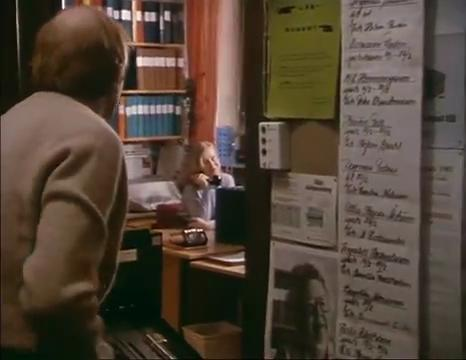

In [11]:
from IPython.display import Image

video_frame = next(frames_dc.limit(1).collect())[0]
Image(video_frame.get_path(), height=360, embed=True)

## Video files processing

For example, let's find all frames with "**write**" action (`action_id = 63`):

In [12]:
from datachain import C

write_frames_dc = annotations_dc.filter(C("action_id") == 63)
write_frames_dc.show(10)

,video_id,timestamp,box_left,box_top,box_right,box_bottom,action_id,person_id
0,-OyDO1g74vc,1342,0.009,0.005,0.630,0.995,63,62
1,-OyDO1g74vc,1343,0.003,0.014,0.610,0.995,63,62
2,-OyDO1g74vc,1344,0.000,0.002,0.599,1.000,63,62
3,-OyDO1g74vc,1345,0.009,0.001,0.601,0.992,63,62
4,-OyDO1g74vc,1346,0.008,0.002,0.609,0.993,63,62
5,-OyDO1g74vc,1347,0.005,0.004,0.615,1.000,63,62
6,-OyDO1g74vc,1348,0.000,0.003,0.578,0.995,63,62
7,-OyDO1g74vc,1349,0.002,0.008,0.593,1.000,63,62
8,-OyDO1g74vc,1350,0.005,0.009,0.570,0.998,63,62
9,-OyDO1g74vc,1351,0.023,0.000,0.603,0.981,63,62



[Limited by 10 rows]


Build fragments from these frames:

In [13]:
from typing import Iterator
from datachain import C, DataModel

class FragmentInterval(DataModel):
    video_id: str
    person_id: int
    start: int
    end: int
    frames: int

def process(video_id, person_id, timestamp) -> Iterator[FragmentInterval]:
    yield FragmentInterval(
        video_id=video_id[0],
        person_id=person_id[0],
        start=timestamp[0],
        end=timestamp[-1],
        frames=len(video_id),
    )

fragments_dc = write_frames_dc.order_by("video_id", "timestamp").agg(
    process,
    output=["fragment"],
    partition_by=[C("video_id"), C("person_id")],
).filter(C("fragment.frames") > 1).save()
fragments_dc.show(10)

Processed: 0 rows [00:00, ? rows/s]

Generated: 0 rows [00:00, ? rows/s]

Cleanup:   0%|          | 0/2 [00:00<?, ? tables/s]

,fragment,fragment,fragment,fragment,fragment
,video_id,person_id,start,end,frames
0,-OyDO1g74vc,62,1342,1357,14
1,-XpUuIgyUHE,288,1367,1369,3
2,2FIHxnZKg6A,100,1130,1131,2
3,2fwni_Kjf2M,45,1117,1118,2
4,3_VjIRdXVdM,275,1491,1493,3
5,4ZpjKfu6Cl8,161,1295,1302,4
6,4ZpjKfu6Cl8,169,1305,1306,2
7,4ZpjKfu6Cl8,173,1313,1314,2
8,5LrOQEt_XVM,299,1671,1679,5



[Limited by 10 rows]


And create video fragments from these frames using `VideoClip` model:

In [14]:
repo_fragment_dc = repo_dc3.merge(
    fragments_dc,
    on="video_id",
    right_on="fragment.video_id",
    inner=True
)
repo_fragment_dc.show(10)

Cleanup:   0%|          | 0/1 [00:00<?, ? tables/s]

,file,file,file,file,file,file,file,file,meta,meta,meta,meta,meta,meta,meta,video_id,fragment,fragment,fragment,fragment,fragment
,source,path,size,version,etag,is_latest,last_modified,location,width,height,fps,duration,frames,format,codec,,video_id,person_id,start,end,frames
0,file:///Users/vlad/work/iterative/datachain-ex...,C3qk4yAMANk.mkv,492664807,,0x1.6a6de12000000p+30,1,2018-03-04 04:38:32+00:00,None,1280,720,29.97003,3443.961000,103216,"matroska,webm",h264,C3qk4yAMANk,C3qk4yAMANk,149,1268,1270,3
1,file:///Users/vlad/work/iterative/datachain-ex...,8VZEwOCQ8bc.mkv,406988513,,0x1.6a6ce0f000000p+30,1,2018-03-04 00:05:16+00:00,None,640,480,25.00000,5226.821000,130670,"matroska,webm",h264,8VZEwOCQ8bc,8VZEwOCQ8bc,169,1771,1775,5
2,file:///Users/vlad/work/iterative/datachain-ex...,cWYJHb25EVs.mp4,307394571,,0x1.6a6e283c00000p+30,1,2018-03-04 05:54:23+00:00,None,624,360,25.00000,6277.816599,156945,"mov,mp4,m4a,3gp,3g2,mj2",h264,cWYJHb25EVs,cWYJHb25EVs,250,1609,1642,9
3,file:///Users/vlad/work/iterative/datachain-ex...,cWYJHb25EVs.mp4,307394571,,0x1.6a6e283c00000p+30,1,2018-03-04 05:54:23+00:00,None,624,360,25.00000,6277.816599,156945,"mov,mp4,m4a,3gp,3g2,mj2",h264,cWYJHb25EVs,cWYJHb25EVs,265,1646,1650,5
4,file:///Users/vlad/work/iterative/datachain-ex...,cWYJHb25EVs.mp4,307394571,,0x1.6a6e283c00000p+30,1,2018-03-04 05:54:23+00:00,None,624,360,25.00000,6277.816599,156945,"mov,mp4,m4a,3gp,3g2,mj2",h264,cWYJHb25EVs,cWYJHb25EVs,267,1657,1658,2
5,file:///Users/vlad/work/iterative/datachain-ex...,cWYJHb25EVs.mp4,307394571,,0x1.6a6e283c00000p+30,1,2018-03-04 05:54:23+00:00,None,624,360,25.00000,6277.816599,156945,"mov,mp4,m4a,3gp,3g2,mj2",h264,cWYJHb25EVs,cWYJHb25EVs,271,1660,1663,4
6,file:///Users/vlad/work/iterative/datachain-ex...,cWYJHb25EVs.mp4,307394571,,0x1.6a6e283c00000p+30,1,2018-03-04 05:54:23+00:00,None,624,360,25.00000,6277.816599,156945,"mov,mp4,m4a,3gp,3g2,mj2",h264,cWYJHb25EVs,cWYJHb25EVs,305,1781,1783,3
7,file:///Users/vlad/work/iterative/datachain-ex...,_Ca3gOdOHxU.mp4,541907613,,0x1.6a6b678000000p+30,1,2018-03-03 17:22:40+00:00,None,854,480,25.00000,5445.381202,136135,"mov,mp4,m4a,3gp,3g2,mj2",h264,_Ca3gOdOHxU,_Ca3gOdOHxU,492,1195,1199,5
8,file:///Users/vlad/work/iterative/datachain-ex...,_Ca3gOdOHxU.mp4,541907613,,0x1.6a6b678000000p+30,1,2018-03-03 17:22:40+00:00,None,854,480,25.00000,5445.381202,136135,"mov,mp4,m4a,3gp,3g2,mj2",h264,_Ca3gOdOHxU,_Ca3gOdOHxU,496,1201,1202,2



[Limited by 10 rows]


In [15]:
from datachain.lib.file import VideoFile, VideoFragment

def process_clip(file: VideoFile, fragment: FragmentInterval) -> Iterator[VideoFragment]:
    yield VideoFragment(
        **file.model_dump(),
        start=fragment.start,
        end=fragment.end,
        orig=file,
    )

video_fragment_dc = repo_fragment_dc.gen(process_clip, output=["file"]).save()
video_fragment_dc.show(10)

Processed: 0 rows [00:00, ? rows/s]

Generated: 0 rows [00:00, ? rows/s]

Cleanup:   0%|          | 0/2 [00:00<?, ? tables/s]

,file,file,file,file,file,file,file,file,file,file,file,file,file,file,file,file,file,file
,source,path,size,version,etag,is_latest,last_modified,location,start,end,orig,orig,orig,orig,orig,orig,orig,orig
,,,,,,,,,,,source,path,size,version,etag,is_latest,last_modified,location
0,file:///Users/vlad/work/iterative/datachain-ex...,C3qk4yAMANk.mkv,492664807,,0x1.6a6de12000000p+30,1,2018-03-04 04:38:32+00:00,None,1268.0,1270.0,file:///Users/vlad/work/iterative/datachain-ex...,C3qk4yAMANk.mkv,492664807,,0x1.6a6de12000000p+30,1,2018-03-04 04:38:32+00:00,None
1,file:///Users/vlad/work/iterative/datachain-ex...,8VZEwOCQ8bc.mkv,406988513,,0x1.6a6ce0f000000p+30,1,2018-03-04 00:05:16+00:00,None,1771.0,1775.0,file:///Users/vlad/work/iterative/datachain-ex...,8VZEwOCQ8bc.mkv,406988513,,0x1.6a6ce0f000000p+30,1,2018-03-04 00:05:16+00:00,None
2,file:///Users/vlad/work/iterative/datachain-ex...,cWYJHb25EVs.mp4,307394571,,0x1.6a6e283c00000p+30,1,2018-03-04 05:54:23+00:00,None,1609.0,1642.0,file:///Users/vlad/work/iterative/datachain-ex...,cWYJHb25EVs.mp4,307394571,,0x1.6a6e283c00000p+30,1,2018-03-04 05:54:23+00:00,None
3,file:///Users/vlad/work/iterative/datachain-ex...,cWYJHb25EVs.mp4,307394571,,0x1.6a6e283c00000p+30,1,2018-03-04 05:54:23+00:00,None,1646.0,1650.0,file:///Users/vlad/work/iterative/datachain-ex...,cWYJHb25EVs.mp4,307394571,,0x1.6a6e283c00000p+30,1,2018-03-04 05:54:23+00:00,None
4,file:///Users/vlad/work/iterative/datachain-ex...,cWYJHb25EVs.mp4,307394571,,0x1.6a6e283c00000p+30,1,2018-03-04 05:54:23+00:00,None,1657.0,1658.0,file:///Users/vlad/work/iterative/datachain-ex...,cWYJHb25EVs.mp4,307394571,,0x1.6a6e283c00000p+30,1,2018-03-04 05:54:23+00:00,None
5,file:///Users/vlad/work/iterative/datachain-ex...,cWYJHb25EVs.mp4,307394571,,0x1.6a6e283c00000p+30,1,2018-03-04 05:54:23+00:00,None,1660.0,1663.0,file:///Users/vlad/work/iterative/datachain-ex...,cWYJHb25EVs.mp4,307394571,,0x1.6a6e283c00000p+30,1,2018-03-04 05:54:23+00:00,None
6,file:///Users/vlad/work/iterative/datachain-ex...,cWYJHb25EVs.mp4,307394571,,0x1.6a6e283c00000p+30,1,2018-03-04 05:54:23+00:00,None,1781.0,1783.0,file:///Users/vlad/work/iterative/datachain-ex...,cWYJHb25EVs.mp4,307394571,,0x1.6a6e283c00000p+30,1,2018-03-04 05:54:23+00:00,None
7,file:///Users/vlad/work/iterative/datachain-ex...,_Ca3gOdOHxU.mp4,541907613,,0x1.6a6b678000000p+30,1,2018-03-03 17:22:40+00:00,None,1195.0,1199.0,file:///Users/vlad/work/iterative/datachain-ex...,_Ca3gOdOHxU.mp4,541907613,,0x1.6a6b678000000p+30,1,2018-03-03 17:22:40+00:00,None



[Limited by 10 rows]


In [16]:
from typing import Iterator
from datachain.lib.file import VideoFragment

def process(file: VideoFragment) -> Iterator[VideoFragment]:
    if not file.get_local_path():
        return
    file_stem = file.get_file_stem()
    file_ext = file.get_file_ext()
    file_name = f"{file_stem}_{int(file.start)}_{int(file.end)}.mp4"
    file_path = f"data/ava/clips/{file_name}"
    yield file.save_fragment(file.start, file.end, file_path)

fragments_dc = video_fragment_dc.gen(process, output=["file"]).save()
fragments_dc.show(10)

Processed: 0 rows [00:00, ? rows/s]

Generated: 0 rows [00:00, ? rows/s]

Cleanup:   0%|          | 0/1 [00:00<?, ? tables/s]

,file,file,file,file,file,file,file,file,file,file,file,file,file,file,file,file,file,file
,source,path,size,version,etag,is_latest,last_modified,location,start,end,orig,orig,orig,orig,orig,orig,orig,orig
,,,,,,,,,,,source,path,size,version,etag,is_latest,last_modified,location
0,file:///Users/vlad/work/iterative/datachain-ex...,C3qk4yAMANk_1268_1270.mp4,350830,,0x1.9e5e7717cfed0p+30,1,2025-01-27 14:52:53.953053+00:00,None,1268.0,1270.0,file:///Users/vlad/work/iterative/datachain-ex...,C3qk4yAMANk.mkv,492664807,,0x1.6a6de12000000p+30,1,2018-03-04 04:38:32+00:00,None
1,file:///Users/vlad/work/iterative/datachain-ex...,8VZEwOCQ8bc_1771_1775.mp4,342356,,0x1.9e5e771a592c3p+30,1,2025-01-27 14:52:54.587083+00:00,None,1771.0,1775.0,file:///Users/vlad/work/iterative/datachain-ex...,8VZEwOCQ8bc.mkv,406988513,,0x1.6a6ce0f000000p+30,1,2018-03-04 00:05:16+00:00,None
2,file:///Users/vlad/work/iterative/datachain-ex...,cWYJHb25EVs_1609_1642.mp4,1616921,,0x1.9e5e7720c0560p+30,1,2025-01-27 14:52:56.187828+00:00,None,1609.0,1642.0,file:///Users/vlad/work/iterative/datachain-ex...,cWYJHb25EVs.mp4,307394571,,0x1.6a6e283c00000p+30,1,2018-03-04 05:54:23+00:00,None
3,file:///Users/vlad/work/iterative/datachain-ex...,_Ca3gOdOHxU_1195_1199.mp4,558933,,0x1.9e5e77251a2fap+30,1,2025-01-27 14:52:57.275572+00:00,None,1195.0,1199.0,file:///Users/vlad/work/iterative/datachain-ex...,_Ca3gOdOHxU.mp4,541907613,,0x1.6a6b678000000p+30,1,2018-03-03 17:22:40+00:00,None
4,file:///Users/vlad/work/iterative/datachain-ex...,4ZpjKfu6Cl8_1295_1302.mp4,1097771,,0x1.9e5e772b26ceap+30,1,2025-01-27 14:52:58.787898+00:00,None,1295.0,1302.0,file:///Users/vlad/work/iterative/datachain-ex...,4ZpjKfu6Cl8.mkv,1037398704,,0x1.6a6c7e9400000p+30,1,2018-03-03 22:20:21+00:00,None
5,file:///Users/vlad/work/iterative/datachain-ex...,2FIHxnZKg6A_1130_1131.mp4,130179,,0x1.9e5e772e37171p+30,1,2025-01-27 14:52:59.553799+00:00,None,1130.0,1131.0,file:///Users/vlad/work/iterative/datachain-ex...,2FIHxnZKg6A.webm,243433226,,0x1.6a6c48c800000p+30,1,2018-03-03 21:22:58+00:00,None
6,file:///Users/vlad/work/iterative/datachain-ex...,2fwni_Kjf2M_1117_1118.mp4,1618845,,0x1.9e5e77340c5f8p+30,1,2025-01-27 14:53:01.012083+00:00,None,1117.0,1118.0,file:///Users/vlad/work/iterative/datachain-ex...,2fwni_Kjf2M.mkv,957263246,,0x1.6a6c4b9800000p+30,1,2018-03-03 21:25:58+00:00,None
7,file:///Users/vlad/work/iterative/datachain-ex...,3_VjIRdXVdM_1491_1493.mp4,232510,,0x1.9e5e773673a8ap+30,1,2025-01-27 14:53:01.612948+00:00,None,1491.0,1493.0,file:///Users/vlad/work/iterative/datachain-ex...,3_VjIRdXVdM.mkv,232670461,,0x1.6a6c64d800000p+30,1,2018-03-03 21:52:54+00:00,None



[Limited by 10 rows]


### Preview video fragment example

In [17]:
from IPython.display import Video

video_fragment = next(fragments_dc.limit(1).collect())[0]
Video(video_fragment.get_path(), height=360, embed=True)